# Example with Soft Classifier Predictions as Target Concepts

This is a demo for the pysubgroup implementation accompanying the paper "SubROC: AUC-Based Discovery of Exceptional Subgroup Performance for Binary Classifiers".

arXiv: [https://arxiv.org/abs/2505.11283](https://arxiv.org/abs/2505.11283)

## Load Data, Train and Predict (preparing the data to mine)

/workspaces/pysubgroup/src/pysubgroup/datasets.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


,index,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,predictions
count,340.000000,340.000000,340.000000,340.000000,340.000000,340.000000,340.000000,340.000000,340.000000
mean,489.450000,21.085294,3504.979412,2.917647,2.850000,36.408824,1.435294,1.144118,0.688886
std,292.942151,12.355182,2939.299232,1.141461,1.117506,12.096487,0.568537,0.351727,0.249383
min,9.000000,4.000000,338.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.062507
25%,220.000000,12.000000,1424.000000,2.000000,2.000000,27.000000,1.000000,1.000000,0.507435
50%,502.500000,18.000000,2406.000000,3.000000,3.000000,33.000000,1.000000,1.000000,0.757686
75%,747.500000,24.000000,4465.500000,4.000000,4.000000,44.000000,2.000000,1.000000,0.904114
max,994.000000,72.000000,15945.000000,4.000000,4.000000,75.000000,4.000000,2.000000,0.991257


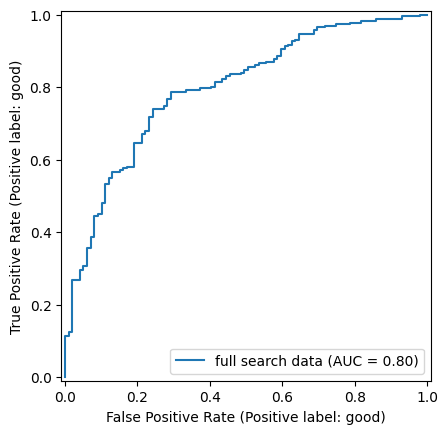

In [1]:
import numpy as np
import pandas as pd
import pysubgroup as ps

from pysubgroup.datasets import get_credit_data

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
from sklearn.exceptions import ConvergenceWarning
from warnings import simplefilter
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

SEED = 0

data = get_credit_data()
label_column = "class"
prediction_column = "predictions"
pos_label = "good"
neg_label = "bad"

# preprocessing
data[label_column] = [pos_label if label == b'good' else neg_label for label in data[label_column]]
categorical_features = ["checking_status", "credit_history", "purpose", "savings_status",
                          "employment", "personal_status", "other_parties", "property_magnitude",
                          "other_payment_plans", "housing", "job", "own_telephone", "foreign_worker"]
other_columns = [column for column in data.columns if column not in categorical_features]
data_categorical_dummies = pd.get_dummies(data.loc[:, categorical_features])
data_new = data_categorical_dummies
data_new[other_columns] = data[other_columns]
data = data_new

# split data in 3 equal parts, each for: training, subgroup discovery, statistical verification of subgroups
train_idx, other_idx = train_test_split(range(len(data)), test_size=0.66, random_state=SEED)
sd_idx, stat_idx = train_test_split(other_idx, test_size=0.5, random_state=SEED)
train_data = data.iloc[train_idx].reset_index()
sd_data = data.iloc[sd_idx].reset_index()
stat_data = data.iloc[stat_idx].reset_index()

# grab the model inputs
def get_X_y(split_data):
    split_X = split_data[split_data.columns[split_data.columns != label_column]]
    split_y = (split_data[label_column] == pos_label).astype("int64")

    return split_X, split_y

train_X, train_y = get_X_y(train_data)
sd_X, sd_y = get_X_y(sd_data)
stat_X, stat_y = get_X_y(stat_data)

# train
simplefilter("ignore", ConvergenceWarning)
model = LogisticRegression(penalty="l2", random_state=SEED)
model.fit(train_X, train_y)

# predict
train_data[prediction_column] = model.predict_proba(train_X)[:, 1]
sd_data[prediction_column] = model.predict_proba(sd_X)[:, 1]
stat_data[prediction_column] = model.predict_proba(stat_X)[:, 1]

# evaluate
roc_display = RocCurveDisplay.from_predictions(sd_data[label_column], sd_data[prediction_column], pos_label=pos_label, name="full search data")

train_data.describe()

## Discover Subgroups

In [2]:
target = ps.SoftClassifierTarget(label_column, prediction_column)  # tell pysubgroup based on which columns to evaluate the model

searchspace = ps.create_selectors(sd_data, ignore=[target.label_column, target.prediction_column])  # tell pysubgroup to generate subgroups based on all but the evaluation attributes
print(f"Search space: {searchspace}")

constraints = [ps.MinSupportConstraint(len(sd_data)/100)]  # tell pysubgroup to not consider too small subgroups

qf = ps.ROCAUCQF(target.label_column, subgroup_class_balance_weight=1, subgroup_size_weight=1)

# define the parameters of the search
task = ps.SubgroupDiscoveryTask(
    sd_data,
    target,
    searchspace,
    result_set_size=100,
    depth=5,
    qf=qf,
    min_quality=0,
    constraints=constraints,
)

result = ps.BestFirstSearch().execute(task)  # run the search algorithm
print(f"Result: {result.results}")

Search space: [checking_status_b'0<=X<200'==False, checking_status_b'0<=X<200'==True, checking_status_b'<0'==True, checking_status_b'<0'==False, checking_status_b'>=200'==False, checking_status_b'>=200'==True, checking_status_b'no checking'==False, checking_status_b'no checking'==True, credit_history_b'all paid'==False, credit_history_b'all paid'==True, credit_history_b'critical/other existing credit'==False, credit_history_b'critical/other existing credit'==True, credit_history_b'delayed previously'==False, credit_history_b'delayed previously'==True, credit_history_b'existing paid'==True, credit_history_b'existing paid'==False, credit_history_b'no credits/all paid'==False, credit_history_b'no credits/all paid'==True, purpose_b'business'==False, purpose_b'business'==True, purpose_b'domestic appliance'==False, purpose_b'domestic appliance'==True, purpose_b'education'==False, purpose_b'education'==True, purpose_b'furniture/equipment'==True, purpose_b'furniture/equipment'==False, purpose_

## Inspect Subgroup Discovery Result

[(16.11950218654796, (checking_status_b'no checking'==False), {}), (10.323861776658976, (checking_status_b'0<=X<200'==True), {}), (8.444831364941551, (age<26.0), {}), (7.582661649978409, (checking_status_b'<0'==True), {}), (3.3928681587637555, (credit_history_b'critical/other existing credit'==False), {}), (3.1271094686412226, (existing_credits==1.0), {}), (3.080708868443441, (employment_b'1<=X<4'==True), {}), (2.823392613602404, (employment_b'unemployed'==True), {}), (2.7609864882592157, (other_parties_b'co applicant'==True), {}), (2.640285148745762, (property_magnitude_b'car'==False), {}), (2.612080399959171, (housing_b'own'==True), {}), (2.555613970650818, (employment_b'4<=X<7'==False), {}), (2.5116631357417605, (job_b'high qualif/self emp/mgmt'==True), {}), (2.4072073218078724, (property_magnitude_b'real estate'==True), {}), (2.3900463909277776, (purpose_b'furniture/equipment'==True), {}), (2.35137085137085, (credit_history_b'delayed previously'==True), {}), (2.3489608625174756, (d

,quality,subgroup,size_sg,ncr
0,16.119502,checking_status_b'no checking'==False,207,0.429952
1,10.323862,checking_status_b'0<=X<200'==True,92,0.434783
2,8.444831,age<26.0,64,0.515625
3,7.582662,checking_status_b'<0'==True,96,0.468750
4,3.392868,credit_history_b'critical/other existing credi...,247,0.360324
...,...,...,...,...
71,0.092431,housing_b'for free'==True,45,0.377778
72,0.076474,purpose_b'other'==False,327,0.296636
73,0.070107,residence_since==3.0,49,0.306122
74,0.056024,job_b'unemp/unskilled non res'==False,324,0.299383


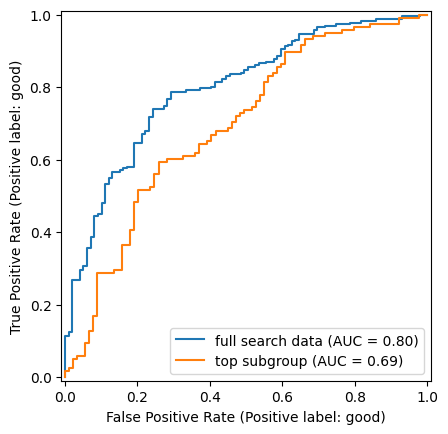

In [3]:
# show the ROC curve of the top (worst-performing) subgroup (orange) vs the ROC curve on all data (blue)
result_subgroups = [ps.create_subgroup_with_representation(sd_data, sg[1].selectors) for sg in result.results]
top_sg_sd_data_cover = sd_data[result_subgroups[0].representation]
roc_display.plot()
top_sg_display = RocCurveDisplay.from_predictions(top_sg_sd_data_cover[target.label_column], top_sg_sd_data_cover[target.prediction_column], pos_label=pos_label, name="top subgroup", ax=roc_display.ax_)

# print the result
print(result.results)
result_df = result.to_dataframe()
result_df["size_sg"] = [sg.size_sg for sg in result_subgroups]
result_df["ncr"] = [sum(sd_data[sg.representation][target.label_column] == neg_label)/sg.size_sg for sg in result_subgroups]
result_df

## Significance Filtering

  0%|          | 0/76 [00:00<?, ?it/s]

skipping subgroup, because its quality undefined on the given data: foreign_worker_b'yes'==False
skipping subgroup, because its quality undefined on the given data: foreign_worker_b'no'==True
Original p-values: [0.0, 0.29, 0.811, 0.0, 0.085, 0.41, 0.12, 0.035, 0.295, 0.174, 0.337, 0.15, 0.014, 0.781, 0.098, 0.341, 0.16, 0.552, 0.023, 0.433, 0.132, 0.006, 0.052, 0.529, 0.428, 0.031, 0.358, 0.009, 0.481, 0.263, 0.55, 0.951, 0.704, 0.005, 0.728, 0.146, 0.878, 0.837, 0.291, 1.0, 1.0, 0.086, 0.539, 0.098, 0.087, 0.108, 0.006, 0.031, 0.861, 0.77, 0.072, 0.524, 0.81, 0.808, 0.068, 0.51, 0.909, 0.702, 0.919, 0.089, 0.78, 0.483, 0.368, 0.709, 0.325, 0.25, 0.08, 0.876, 0.477, 1.0, 0.418, 0.174, 0.834, 0.115, 0.048, 0.452]
Corrected p-values: [0.         1.         1.         0.         1.         1.
 1.         1.         1.         1.         1.         1.
 0.74700606 1.         1.         1.         1.         1.
 1.         1.         1.         0.44820363 1.         1.
 1.         1.        

/tmp/ipykernel_1919603/1840323678.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_test_results_df.sort_values(by="q", ascending=False, inplace=True)  # sort such that highest quality subgroups are first


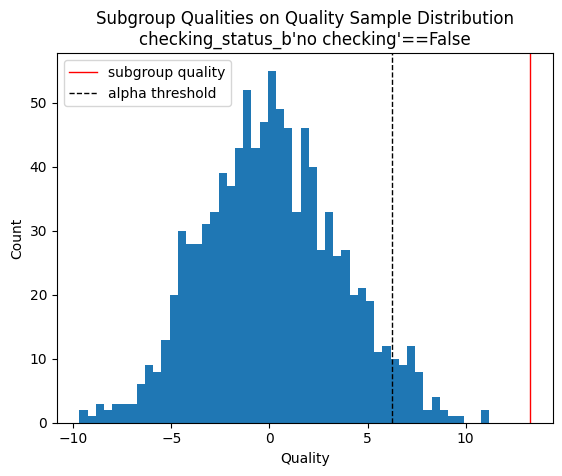

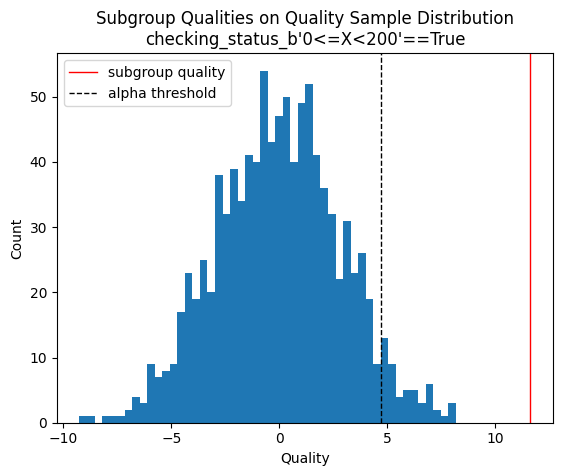

In [4]:
# make sure that the constant stats on the qf match the data you test on
qf.calculate_constant_statistics(stat_data, target)

p_values_raw, reject, p_values_corrected, qualities, samples = ps.permutation_test(
    qf=qf,
    result=result,
    target=target,
    data=stat_data,
    num_random_samples=1000,
    np_rng=np.random.default_rng(SEED),
    max_random_sampling_retries=10,
    alpha=0.05,
    pos_label=pos_label,
    neg_label=neg_label,
    multitest_correction_method="fdr_by",
    tqdm=tqdm,
)

print(f"Original p-values: {p_values_raw}")
print(f"Corrected p-values: {p_values_corrected}")
print(f"Final significance outcomes: {reject}")

test_results_df = pd.DataFrame({"pr": p_values_raw, "r": reject, "pc": p_values_corrected, "q": qualities, "s": samples})
filtered_test_results_df = test_results_df[test_results_df["r"]]  # select only the subgroups that passed the test (including multitest correction)
filtered_test_results_df.sort_values(by="q", ascending=False, inplace=True)  # sort such that highest quality subgroups are first
filtered_test_results_df = filtered_test_results_df[:5]  # select only the top-5 subgroups, that also passed the statistical test

# plot each subgroup quality on its sample distribution with a fixed alpha for reference
# note that this is not actually the effective significance threshold becaues of the multiple comparison correction
figs = ps.plot_qualities_on_sample_distribution(result, filtered_test_results_df["q"], filtered_test_results_df["s"], alpha=0.05, side="right", bins=50)
for fig in figs:
    plt.show(fig)